In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
training_dataset_path = "./data/training_data/training_dataset.parquet"

df = pd.read_parquet(training_dataset_path)

Classification Report:
              precision    recall  f1-score   support

         0.0      0.643     0.409     0.500        22
         1.0      0.912     0.964     0.938       140

    accuracy                          0.889       162
   macro avg      0.778     0.687     0.719       162
weighted avg      0.876     0.889     0.878       162



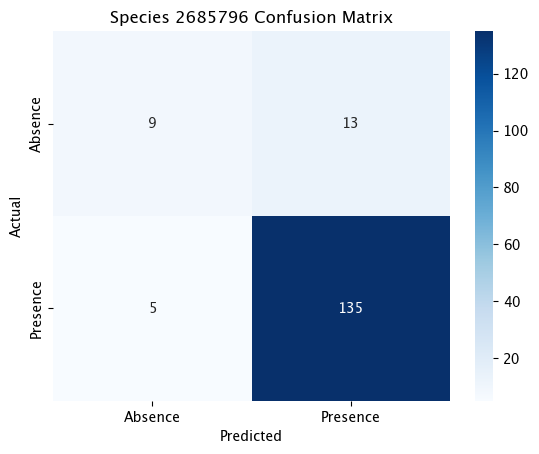

In [4]:


# --- Load your dataset (if not already loaded) ---
# df = pd.read_csv("your_data.csv")

# --- Features and target ---
band_cols = [col for col in df.columns if col.startswith("band_")]
target_col = "2685796"  # your species column (presence/absence)

df_clean = df.dropna(subset=[target_col])
X = df_clean[band_cols]
y = df_clean[target_col]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Model training ---
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# --- Predictions ---
y_pred = clf.predict(X_test)

# --- Metrics ---
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Absence", "Presence"],
            yticklabels=["Absence", "Presence"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Species {target_col} Confusion Matrix")
plt.show()


In [5]:
# --- Drop missing values from target ---import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier  # Uncomment if working

# --- Define your features and target ---
target_col = "2685796"
X = df[[col for col in df.columns if col.startswith("band_")]].copy()
y = df[target_col].fillna(0).astype(int)  # ensure no NaNs

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Define models ---
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "XGBoost": XGBClassifier(scale_pos_weight=(y == 0).sum() / (y == 1).sum(), use_label_encoder=False, eval_metric='logloss', verbosity=0),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=42),
}

# --- Evaluate each model ---
results = []
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# --- Display results ---
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 419, number of negative: 750
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55722
[LightGBM] [Info] Number of data points in the train set: 1169, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [6]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.974359,0.971014,0.957143,0.964029
1,Logistic Regression,0.966667,0.950355,0.957143,0.953737
2,HistGradientBoosting,0.966667,0.977444,0.928571,0.952381
3,LightGBM,0.964103,0.963235,0.935714,0.949275
4,Random Forest,0.964103,0.977273,0.921429,0.948529
5,SVM (RBF Kernel),0.874359,0.797386,0.871429,0.832765


In [7]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- Prepare data ---
target_col = "2685796"
df_clean = df.dropna(subset=[target_col])
X = df_clean[[col for col in df_clean.columns if col.startswith("band_")]]
y = df_clean[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Define models ---
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ),
}

# --- Loop through models and print classification reports ---
for name, model in models.items():
    print(f"\n🔍 {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))



🔍 Random Forest
Classification Report:
              precision    recall  f1-score   support

           0      0.643     0.409     0.500        22
           1      0.912     0.964     0.938       140

    accuracy                          0.889       162
   macro avg      0.778     0.687     0.719       162
weighted avg      0.876     0.889     0.878       162


🔍 Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0      0.667     0.727     0.696        22
           1      0.957     0.943     0.950       140

    accuracy                          0.914       162
   macro avg      0.812     0.835     0.823       162
weighted avg      0.917     0.914     0.915       162


🔍 SVM (RBF Kernel)


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:
              precision    recall  f1-score   support

           0      0.500     0.727     0.593        22
           1      0.954     0.886     0.919       140

    accuracy                          0.864       162
   macro avg      0.727     0.806     0.756       162
weighted avg      0.892     0.864     0.874       162


🔍 HistGradientBoosting
Classification Report:
              precision    recall  f1-score   support

           0      0.750     0.545     0.632        22
           1      0.932     0.971     0.951       140

    accuracy                          0.914       162
   macro avg      0.841     0.758     0.791       162
weighted avg      0.907     0.914     0.908       162


🔍 XGBoost


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0      0.625     0.682     0.652        22
           1      0.949     0.936     0.942       140

    accuracy                          0.901       162
   macro avg      0.787     0.809     0.797       162
weighted avg      0.905     0.901     0.903       162



# All species

In [8]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pandas as pd

# --- Output file ---
output_path = "species_model_reports.txt"

# --- Get list of spectral band columns ---
band_cols = [col for col in df.columns if col.startswith("band_")]

# --- Get list of species target columns (assumes GBIF taxon IDs) ---
species_cols = [col for col in df.columns if col not in band_cols
                and col not in ['plot_id', 'scene_id', 'pixel_id', 'row', 'col', 'centroid']
                and str(col).isdigit()]

# --- Define models ---
def get_models(y_train):
    return {
        "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
        "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
        "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
        "HistGradientBoosting": HistGradientBoostingClassifier(),
        "XGBoost": XGBClassifier(
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42
        ),
    }

# --- Run all models and capture results ---
results = []

for species_col in species_cols:
    df_clean = df.dropna(subset=[species_col])
    if df_clean[species_col].nunique() < 2:
        continue  # Skip species with only 1 class
    
    X = df_clean[band_cols]
    y = df_clean[species_col].astype(int)

    if len(y) < 40:
        continue

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, stratify=y, test_size=0.25, random_state=42
        )
    except ValueError:
        continue  # Skip if stratified split fails

    header = f"\n\n==========================\n📌 Species: {species_col} ({(y==1).sum()} positive samples)\n=========================="
    results.append(header)

    for name, model in get_models(y_train).items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, digits=3)
        entry = f"\n🔍 {name}\nClassification Report:\n{report}"
        results.append(entry)

# --- Write to file ---
with open(output_path, "w") as f:
    f.write("\n".join(results))


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:41:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: Conve

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

def plot_feature_importance(df, species_col, model_name="Random Forest", top_n=30):
    # --- Prepare data ---
    df_clean = df.dropna(subset=[species_col])
    X = df_clean[[col for col in df_clean.columns if col.startswith("band_")]]
    y = df_clean[species_col].astype(int)

    # --- Train model ---
    model = RandomForestClassifier(class_weight="balanced", random_state=42)
    model.fit(X, y)

    # --- Get importances ---
    importances = model.feature_importances_
    band_names = X.columns
    importance_df = pd.DataFrame({
        "band": band_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    # --- Plot ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(top_n), x="band", y="importance", palette="viridis")
    plt.xticks(rotation=90)
    plt.title(f"Top {top_n} Most Important Bands for Species {species_col} ({model_name})")
    plt.tight_layout()
    plt.show()

    return importance_df


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/4052966340.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(top_n), x="band", y="importance", palette="viridis")


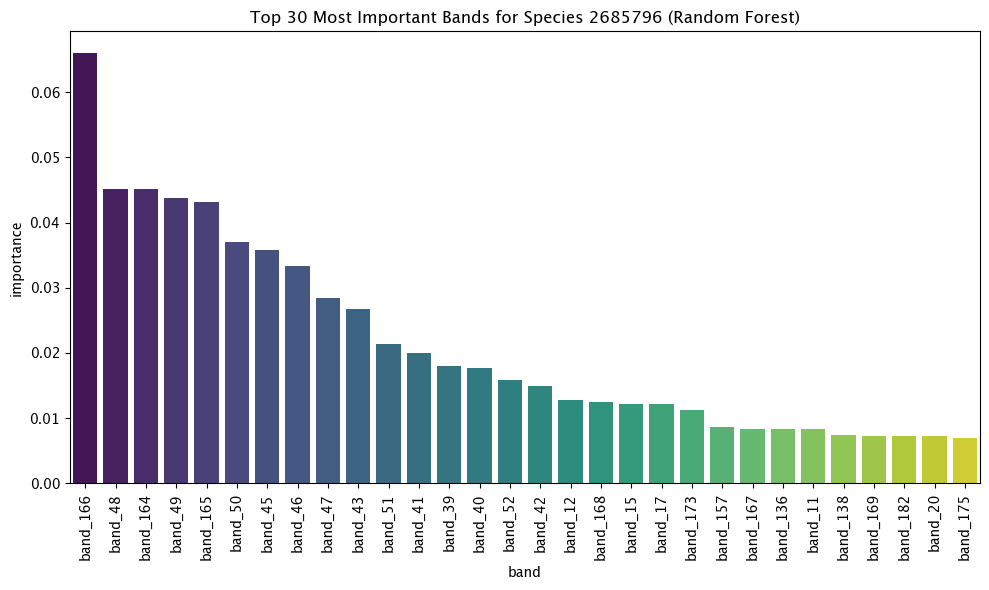

In [10]:
imp_df = plot_feature_importance(df, species_col="2685796", model_name="Random Forest")


In [17]:
import numpy as np

# Approximate EnMAP wavelength centers, interpolated
wavelengths = np.linspace(420, 2450, 224)  # You can refine this if you have exact centers


In [18]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_spectral_feature_importance(df, species_col, wavelengths, model_name="Random Forest"):
    # --- Prepare data ---
    df_clean = df.dropna(subset=[species_col])
    X = df_clean[[col for col in df_clean.columns if col.startswith("band_")]]
    y = df_clean[species_col].astype(int)

    # --- Train model ---
    model = RandomForestClassifier(class_weight="balanced", random_state=42)
    model.fit(X, y)

    # --- Extract importances ---
    importances = model.feature_importances_
    
    # --- Plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(wavelengths, importances, marker='o', lw=1)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Feature Importance")
    plt.title(f"Spectral Feature Importance for Species {species_col} ({model_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


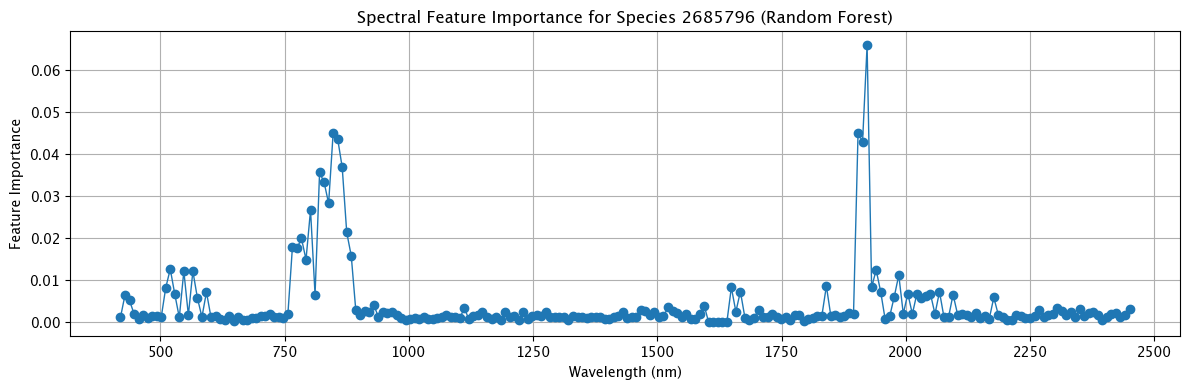

In [19]:
plot_spectral_feature_importance(df, species_col="2685796", wavelengths=wavelengths)


In [53]:
import pandas as pd

# Load the spectral band file
band_df = pd.read_excel("./data/enmap_downloads/EnMAP_Spectral_Bands.xlsx")

# Create a lookup array of center wavelengths
center_wavelengths = band_df["CW (nm)"].values
fwhm = band_df["FWHM (nm)"].values


In [19]:
import pandas as pd
import xml.etree.ElementTree as ET

xml_path = "./data/enmap_downloads/enmap_band_characterisation.xml"  # path to your XML file

# Parse XML
tree = ET.parse(xml_path)
root = tree.getroot()

records = []
for band in root.findall(".//bandID"):
    number = int(band.attrib["number"])
    cw = float(band.find("wavelengthCenterOfBand").text)
    fwhm = float(band.find("FWHMOfBand").text)
    gain = float(band.find("GainOfBand").text)
    offset = float(band.find("OffsetOfBand").text)
    records.append((number, cw, fwhm, gain, offset))

# Create DataFrame
band_df = pd.DataFrame(
    records,
    columns=["BAND #", "CW (nm)", "FWHM (nm)", "Gain", "Offset"]
)

# Sort just in case
band_df = band_df.sort_values("BAND #").reset_index(drop=True)

print(band_df.head())
print(len(band_df), "bands loaded")


   BAND #  CW (nm)  FWHM (nm)    Gain  Offset
0       1  418.416    6.99561  0.0001     0.0
1       2  424.043    6.66750  0.0001     0.0
2       3  429.457    6.42408  0.0001     0.0
3       4  434.686    6.25124  0.0001     0.0
4       5  439.758    6.13485  0.0001     0.0
224 bands loaded


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_avg_spectrum_with_band_importance(
    df: pd.DataFrame,
    species_code: str,
    band_df: pd.DataFrame,
    title_prefix: str = "Average Spectrum + Band Importances",
    derivative_order: int = 0,
    red_alpha_range=(0.02, 0.30),
    red_gamma: float = 0.7,
    respect_masks: bool = True,
    gap_alpha: float = 0.18,                # blue shading transparency
    gap_color: str = "#76a5ff",             # blue shading color
    drop_alpha: float = 0.35,               # dropped-band shading (gray)
    keep_ranges_nm=None,                    # usable ranges; default = EnMAP windows
):
    """
    Average spectra for classes 0/1 with vertical red bands (per-band
    importances). We *only* draw spectra inside `keep_ranges_nm` and
    shade everything outside those windows in light blue.
    """

    if keep_ranges_nm is None:
        # Typical EnMAP L2A usable ranges
        keep_ranges_nm = [(430, 1340), (1450, 1780), (1980, 2450)]

    # ---- X, y ----
    band_cols = [c for c in df.columns if c.startswith("band_")]
    if not band_cols:
        raise ValueError("No band_* columns found in df.")
    X = df[band_cols].to_numpy(dtype=float)

    if species_code not in df.columns:
        raise ValueError(f"Target '{species_code}' not found in df.")
    y = df[species_code].to_numpy(dtype=float)

    keep_rows = ~np.isnan(y)
    X, y = X[keep_rows], y[keep_rows].astype(int)
    n_bands = X.shape[1]

    # ---- Dropped bands via sentinel ----
    bad_band = np.any(X == -32768, axis=0)
    X[X == -32768] = np.nan

    # ---- Importances (median-impute) ----
    rf = RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1
    )
    col_med = np.nanmedian(X, axis=0)
    X_train = np.where(np.isnan(X), col_med, X)
    rf.fit(X_train, y)
    importances = rf.feature_importances_

    # ---- Wavelength centers & edges from band_df ----
    def get_series(name_variants):
        for nv in name_variants:
            for col in band_df.columns:
                if str(col).strip().lower() == nv:
                    return band_df[col].to_numpy()
        return None

    start = get_series(["start wl", "startwl", "start_wl"])
    end   = get_series(["end wl", "endwl", "end_wl"])
    mid   = get_series(["middle wl", "middlewl", "cw (nm)", "cw", "center wl", "centerwl"])
    width = get_series(["fwhm (nm)", "fwhm", "sp.rg.", "spectral range", "sp rg", "sp_rg"])

    if start is not None and end is not None:
        centers = 0.5 * (start + end)
        left_edges = start
        right_edges = end
    elif (mid is not None) and (width is not None):
        centers = mid
        left_edges = mid - width / 2.0
        right_edges = mid + width / 2.0
    elif mid is not None:
        centers = mid
        edges = np.zeros(len(centers) + 1, dtype=float)
        edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
        first_gap = centers[1] - centers[0]
        last_gap = centers[-1] - centers[-2]
        edges[0] = centers[0] - first_gap / 2.0
        edges[-1] = centers[-1] + last_gap / 2.0
        left_edges = edges[:-1]
        right_edges = edges[1:]
    else:
        raise ValueError("band_df needs either Start+End WL, or Middle/CW (nm) (±width).")

    centers    = centers[:n_bands]
    left_edges = left_edges[:n_bands]
    right_edges= right_edges[:n_bands]

    # ---- Sort by wavelength ----
    order = np.argsort(centers)
    wl       = centers[order]
    wl_left  = left_edges[order]
    wl_right = right_edges[order]
    imp      = importances[order]
    bad_sorted = bad_band[order]

    # ---- Build 'in_keep' mask from keep_ranges_nm ----
    in_keep = np.zeros_like(wl, dtype=bool)
    for a, b in keep_ranges_nm:
        in_keep |= (wl >= a) & (wl <= b)

    # ---- Class means ----
    mean0 = np.nanmean(X[y == 0], axis=0)[order]
    mean1 = np.nanmean(X[y == 1], axis=0)[order]

    # also treat non-finite means as invalid
    invalid0 = bad_sorted | (~in_keep) | (~np.isfinite(mean0))
    invalid1 = bad_sorted | (~in_keep) | (~np.isfinite(mean1))

    m0 = np.ma.array(mean0, mask=invalid0)
    m1 = np.ma.array(mean1, mask=invalid1)

    # ---- Optional derivative ----
    def masked_derivative(vals_ma, x, n):
        if n <= 0:
            return vals_ma
        out = vals_ma.copy()
        for _ in range(n):
            arr = out.filled(np.nan)
            darr = np.gradient(arr, x)
            out = np.ma.masked_invalid(darr)
            out.mask = np.logical_or(out.mask, vals_ma.mask)
        return out

    m0 = masked_derivative(m0, wl, derivative_order)
    m1 = masked_derivative(m1, wl, derivative_order)

    # ---- Red alpha per band (zero outside keep or masked) ----
    imp_norm = imp / imp.max() if imp.max() > 0 else np.zeros_like(imp)
    a_min, a_max = red_alpha_range
    alpha_red = a_min + (a_max - a_min) * (imp_norm ** red_gamma)
    blocked = (~in_keep) | bad_sorted
    if respect_masks:
        alpha_red = np.where(blocked, 0.0, alpha_red)

    # ---- Helper to make spans from a boolean mask over bands ----
    def spans_from_bool(left, right, flag_true):
        spans = []
        i, n = 0, len(flag_true)
        while i < n:
            if flag_true[i]:
                j = i
                while j + 1 < n and flag_true[j + 1]:
                    j += 1
                spans.append((left[i], right[j]))
                i = j + 1
            else:
                i += 1
        return spans

    # Spans to shade: everything OUTSIDE the keep ranges
    outside_spans = spans_from_bool(wl_left, wl_right, ~in_keep)

    # --------------- Plot ----------------
    fig, ax = plt.subplots(figsize=(12, 5.6))

    # 0) Shade outside-keep regions in light blue
    for L, R in outside_spans:
        ax.axvspan(L, R, color=gap_color, alpha=gap_alpha, zorder=0, linewidth=0)

    # 1) Red importance spans (only inside keep + not dropped)
    for L, R, a, ok in zip(wl_left, wl_right, alpha_red, ~blocked):
        if ok and a > 0:
            ax.axvspan(L, R, color="red", alpha=a, zorder=1, linewidth=0)

    # 2) Dropped/masked bands (gray)
    masked_idx = np.where(bad_sorted & in_keep)[0]
    if masked_idx.size:
        runs = np.split(masked_idx, np.where(np.diff(masked_idx) != 1)[0] + 1)
        for r in runs:
            L = wl_left[r[0]]
            R = wl_right[r[-1]]
            ax.axvspan(L, R, color="gray", alpha=drop_alpha, zorder=2, linewidth=0)

    # Pick consistent colors for all segments
    color0 = "C0"  # default matplotlib first color (blue)
    color1 = "C1"  # default matplotlib second color (orange)

    # 3) Plot spectra in contiguous segments strictly within keep ranges
    def plot_segmented(ax, x, y_ma, label=None, color=None, **kw):
        mask = np.asarray(y_ma.mask, dtype=bool)
        start = None
        first_line = None
        for i in range(len(x)):
            if mask[i]:
                if start is not None:
                    ln, = ax.plot(x[start:i], y_ma.data[start:i], color=color, **kw)
                    if first_line is None and label is not None:
                        ln.set_label(label)
                        first_line = ln
                    start = None
            else:
                if start is None:
                    start = i
        if start is not None:
            ln, = ax.plot(x[start:], y_ma.data[start:], color=color, **kw)
            if first_line is None and label is not None:
                ln.set_label(label)
                first_line = ln
        return first_line

    # Call with fixed colors
    line0 = plot_segmented(ax, wl, m0, label="class 0", color=color0, linewidth=1.4, zorder=3)
    line1 = plot_segmented(ax, wl, m1, label="class 1", color=color1, linewidth=1.4, zorder=3)


    # Y-lims ignoring masked
    vals = np.concatenate([m0.compressed(), m1.compressed()])
    if vals.size:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        pad = 0.03 * (vmax - vmin if vmax > vmin else 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)

    # Labels / legend
    ylab = "Reflectance" if derivative_order == 0 else f"{derivative_order}ᵗʰ derivative"
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title_prefix} — species {species_code} — derivative: {derivative_order}")
    ax.grid(True, alpha=0.25)

    from matplotlib.patches import Patch
    red_patch  = Patch(facecolor="red",  alpha=0.4, label="band importance (deeper red = higher)")
    gap_patch  = Patch(facecolor=gap_color, alpha=gap_alpha, label="instrument band gaps")
    drop_patch = Patch(facecolor="gray", alpha=drop_alpha, label="dropped bands")
    ax.legend(handles=[line0, line1, red_patch, gap_patch, drop_patch], loc="best")

    plt.tight_layout()
    plt.show()


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_avg_spectrum_with_band_importance(
    df: pd.DataFrame,
    species_code: str,
    band_df: pd.DataFrame,
    title_prefix: str = "Average Spectrum + Band Importances",
    derivative_order: int = 0,
    red_alpha_range=(0.02, 0.30),
    red_gamma: float = 0.7,
    respect_masks: bool = True,
    gap_alpha: float = 0.18,                # blue shading transparency
    gap_color: str = "#76a5ff",             # blue shading color
    drop_alpha: float = 0.35,               # dropped-band shading (gray)
    keep_ranges_nm=None,                    # usable ranges; default = EnMAP windows
):
    """
    Average spectra for classes 0/1 with vertical red bands (per-band
    importances). We *only* draw spectra inside `keep_ranges_nm` and
    shade everything outside those windows in light blue.
    """

    if keep_ranges_nm is None:
        keep_ranges_nm = [(430, 1340), (1450, 1780), (1980, 2450)]

    # ---- X, y ----
    band_cols = [c for c in df.columns if c.startswith("band_")]
    if not band_cols:
        raise ValueError("No band_* columns found in df.")
    X = df[band_cols].to_numpy(dtype=float)

    if species_code not in df.columns:
        raise ValueError(f"Target '{species_code}' not found in df.")
    y = df[species_code].to_numpy(dtype=float)

    keep_rows = ~np.isnan(y)
    X, y = X[keep_rows], y[keep_rows].astype(int)
    n_bands = X.shape[1]

    # ---- Dropped bands via sentinel ----
    bad_band = np.any(X == -32768, axis=0)
    X[X == -32768] = np.nan

    # ---- Importances (median-impute) ----
    rf = RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1
    )
    col_med = np.nanmedian(X, axis=0)
    X_train = np.where(np.isnan(X), col_med, X)
    rf.fit(X_train, y)
    importances = rf.feature_importances_

    # ---- Wavelength centers & edges from band_df ----
    def get_series(name_variants):
        for nv in name_variants:
            for col in band_df.columns:
                if str(col).strip().lower() == nv:
                    return band_df[col].to_numpy()
        return None

    start = get_series(["start wl", "startwl", "start_wl"])
    end   = get_series(["end wl", "endwl", "end_wl"])
    mid   = get_series(["middle wl", "middlewl", "cw (nm)", "cw", "center wl", "centerwl"])
    width = get_series(["fwhm (nm)", "fwhm", "sp.rg.", "spectral range", "sp rg", "sp_rg"])

    if start is not None and end is not None:
        centers = 0.5 * (start + end)
        left_edges = start
        right_edges = end
    elif (mid is not None) and (width is not None):
        centers = mid
        left_edges = mid - width / 2.0
        right_edges = mid + width / 2.0
    elif mid is not None:
        centers = mid
        edges = np.zeros(len(centers) + 1, dtype=float)
        edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
        first_gap = centers[1] - centers[0]
        last_gap = centers[-1] - centers[-2]
        edges[0] = centers[0] - first_gap / 2.0
        edges[-1] = centers[-1] + last_gap / 2.0
        left_edges = edges[:-1]
        right_edges = edges[1:]
    else:
        raise ValueError("band_df needs either Start+End WL, or Middle/CW (nm) (±width).")

    centers    = centers[:n_bands]
    left_edges = left_edges[:n_bands]
    right_edges= right_edges[:n_bands]

    # ---- Sort by wavelength ----
    order = np.argsort(centers)
    wl       = centers[order]
    wl_left  = left_edges[order]
    wl_right = right_edges[order]
    imp      = importances[order]
    bad_sorted = bad_band[order]

    # ---- Build 'in_keep' mask from keep_ranges_nm ----
    in_keep = np.zeros_like(wl, dtype=bool)
    for a, b in keep_ranges_nm:
        in_keep |= (wl >= a) & (wl <= b)

    # ---- Class means ----
    mean0 = np.nanmean(X[y == 0], axis=0)[order]
    mean1 = np.nanmean(X[y == 1], axis=0)[order]

    invalid0 = bad_sorted | (~in_keep) | (~np.isfinite(mean0))
    invalid1 = bad_sorted | (~in_keep) | (~np.isfinite(mean1))

    m0 = np.ma.array(mean0, mask=invalid0)
    m1 = np.ma.array(mean1, mask=invalid1)

    # ---- Optional derivative ----
    def masked_derivative(vals_ma, x, n):
        if n <= 0:
            return vals_ma
        out = vals_ma.copy()
        for _ in range(n):
            arr = out.filled(np.nan)
            darr = np.gradient(arr, x)
            out = np.ma.masked_invalid(darr)
            out.mask = np.logical_or(out.mask, vals_ma.mask)
        return out

    m0 = masked_derivative(m0, wl, derivative_order)
    m1 = masked_derivative(m1, wl, derivative_order)

    # ---- Red alpha per band (zero outside keep or masked) ----
    imp_norm = imp / imp.max() if imp.max() > 0 else np.zeros_like(imp)
    a_min, a_max = red_alpha_range
    alpha_red = a_min + (a_max - a_min) * (imp_norm ** red_gamma)
    blocked = (~in_keep) | bad_sorted
    if respect_masks:
        alpha_red = np.where(blocked, 0.0, alpha_red)

    # --------------- Plot ----------------
    fig, ax = plt.subplots(figsize=(12, 5.6))

    # 0) Shade ALL regions outside keep ranges (complement over full domain)
    dom_L = float(np.min(wl_left))
    dom_R = float(np.max(wl_right))
    # normalize/clip & sort keep windows
    keep_sorted = sorted([(max(dom_L, a), min(dom_R, b)) for a, b in keep_ranges_nm if b > dom_L and a < dom_R])
    cur = dom_L
    for a, b in keep_sorted:
        if a > cur:
            ax.axvspan(cur, a, color=gap_color, alpha=gap_alpha, zorder=0, linewidth=0)
        cur = max(cur, b)
    if cur < dom_R:
        ax.axvspan(cur, dom_R, color=gap_color, alpha=gap_alpha, zorder=0, linewidth=0)

    # 1) Red importance spans (only inside keep + not dropped)
    for L, R, a, ok in zip(wl_left, wl_right, alpha_red, ~blocked):
        if ok and a > 0:
            ax.axvspan(L, R, color="red", alpha=a, zorder=1, linewidth=0)

    # 2) Dropped/masked bands (gray) inside keep windows
    masked_idx = np.where(bad_sorted & in_keep)[0]
    if masked_idx.size:
        runs = np.split(masked_idx, np.where(np.diff(masked_idx) != 1)[0] + 1)
        for r in runs:
            L = wl_left[r[0]]
            R = wl_right[r[-1]]
            ax.axvspan(L, R, color="gray", alpha=drop_alpha, zorder=2, linewidth=0)

    # Keep spectrum line colors consistent across segments
    color0 = "C0"
    color1 = "C1"

    # 3) Plot spectra in contiguous segments strictly within keep ranges
    def plot_segmented(ax, x, y_ma, label=None, color=None, **kw):
        mask = np.asarray(y_ma.mask, dtype=bool)
        start = None
        first_line = None
        for i in range(len(x)):
            if mask[i]:
                if start is not None:
                    ln, = ax.plot(x[start:i], y_ma.data[start:i], color=color, **kw)
                    if first_line is None and label is not None:
                        ln.set_label(label); first_line = ln
                    start = None
            else:
                if start is None:
                    start = i
        if start is not None:
            ln, = ax.plot(x[start:], y_ma.data[start:], color=color, **kw)
            if first_line is None and label is not None:
                ln.set_label(label); first_line = ln
        return first_line

    line0 = plot_segmented(ax, wl, m0, label="class 0", color=color0, linewidth=1.4, zorder=3)
    line1 = plot_segmented(ax, wl, m1, label="class 1", color=color1, linewidth=1.4, zorder=3)

    # Y-lims ignoring masked
    vals = np.concatenate([m0.compressed(), m1.compressed()])
    if vals.size:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        pad = 0.03 * (vmax - vmin if vmax > vmin else 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)

    # Labels / legend
    ylab = "Reflectance" if derivative_order == 0 else f"{derivative_order}ᵗʰ derivative"
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title_prefix} — species {species_code} — derivative: {derivative_order}")
    ax.grid(True, alpha=0.25)

    from matplotlib.patches import Patch
    red_patch  = Patch(facecolor="red",  alpha=0.4, label="band importance (deeper red = higher)")
    gap_patch  = Patch(facecolor=gap_color, alpha=gap_alpha, label="instrument band gaps")
    drop_patch = Patch(facecolor="gray", alpha=drop_alpha, label="dropped bands")
    ax.legend(handles=[line0, line1, red_patch, gap_patch, drop_patch], loc="best")

    plt.tight_layout()
    plt.show()


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/2061718255.py:51: RuntimeWarning: All-NaN slice encountered
  col_med = np.nanmedian(X, axis=0)
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/2061718255.py:108: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/2061718255.py:109: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


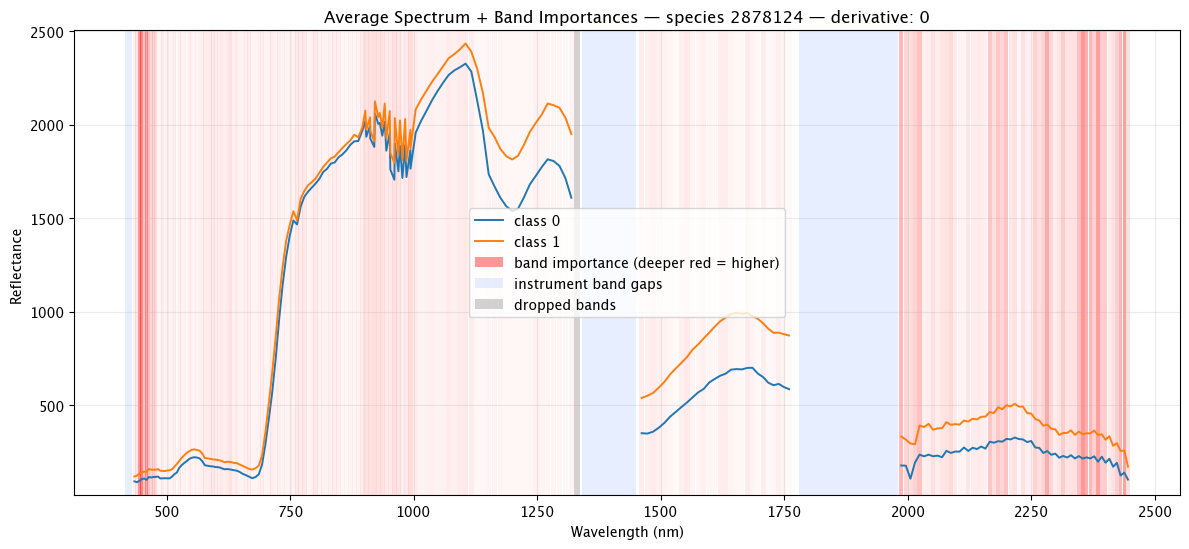

In [55]:
# Typical EnMAP L2A usable ranges
enmap_keep = [(430, 1340), (1450, 1780), (1980, 2450)]

plot_avg_spectrum_with_band_importance(
    df,
    species_code="2878124",
    band_df=band_df,                 # parsed from your XML or CSV
    derivative_order=0,
    # keep_ranges_nm=enmap_keep,       # optional (defaults to these)
    # min_valid_frac=0.7,              # ignore bands with too many NaNs
    # autoscale_reflectance=True,      # divide by 10000 if needed
    red_alpha_range=(0.02, 0.5),    # tone down red
)
